# Applied Statistics for Data Science with Python


# Chapter 4: Hypothesis Testing & Statistical Comparison Methods

by Gal Arav M.Sc. © 2026  
Licensed under the MIT LICENSE  

<a href="https://qikly.com/?utm_source=colab&utm_medium=notebook&utm_campaign=colab_referral" target="_blank">qikly.com</a>

## Learning Objectives  

This notebook accompanies the book's Chapter 4 with these objectives:

- Understand the structure of hypothesis tests, including null and alternative hypotheses
- Interpret p values as evidence rather than all or nothing decisions
- Distinguish Type I and Type II errors and relate them to statistical power
- Explain how effect size and sample size influence the detectability of differences
- Use simulated data to compare groups and evaluate test performance
- Apply parametric and nonparametric tests for group comparisons
- Construct and interpret Q-Q plots to assess distributional assumptions
- Interpret distribution overlap measures such as OVL and CLES
- Compute and interpret correlation coefficients and rank based association measures
- Visualize and explain linear and nonlinear relationships between variables









In [ ]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Group Comparisons

### Simulated Data for Group Comparisons


#### Scenario 1: Location Differences (Different Mean, Same Variance)

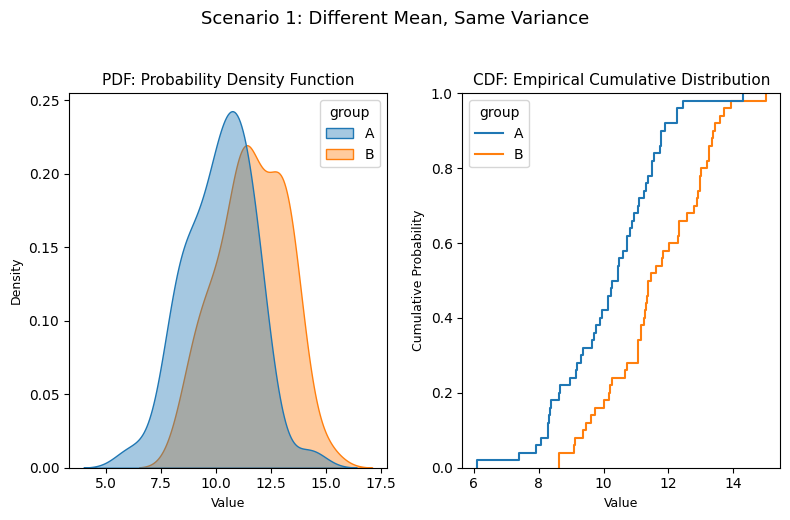

In [ ]:
# ============================================================
# Scenario 1: Location Differences (Different Mean, Same Variance)
# PDF vs CDF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
rng = np.random.default_rng(seed=SEED)

# Simulated data
n_a, n_b = 50, 50
values_a = rng.normal(loc=10, scale=2, size=n_a)
values_b = rng.normal(loc=12, scale=2, size=n_b)

df1 = pd.DataFrame({
    "group": ["A"] * n_a + ["B"] * n_b,
    "value": np.concatenate([values_a, values_b])
})

# ------------------------------------------------------------
# Visualization (8×5)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.kdeplot(
    data=df1, x="value", hue="group",
    fill=True, common_norm=False, alpha=0.4, ax=axes[0]
)
axes[0].set_title("PDF: Probability Density Function", fontsize=11)
axes[0].set_xlabel("Value", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)

# CDF
sns.ecdfplot(data=df1, x="value", hue="group", ax=axes[1])
axes[1].set_title("CDF: Empirical Cumulative Distribution", fontsize=11)
axes[1].set_xlabel("Value", fontsize=9)
axes[1].set_ylabel("Cumulative Probability", fontsize=9)

fig.suptitle("Scenario 1: Different Mean, Same Variance", fontsize=13, y=1.03)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_location_difference")


#### Scenario 2: Scale Differences (Same Mean, Different Variance)

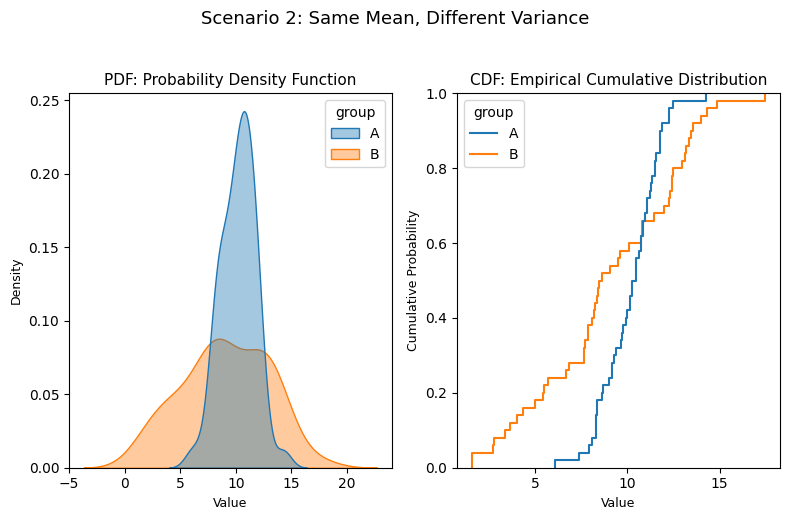

In [ ]:
# ============================================================
# Scenario 2: Scale Differences (Same Mean, Different Variance)
# PDF vs CDF
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
rng = np.random.default_rng(seed=SEED)

# Simulated data
n_a, n_b = 50, 50
values_a = rng.normal(loc=10, scale=2, size=n_a)   # mean 10, sd 2
values_b = rng.normal(loc=10, scale=5, size=n_b)   # mean 10, sd 5

df2 = pd.DataFrame({
    "group": ["A"] * n_a + ["B"] * n_b,
    "value": np.concatenate([values_a, values_b])
})

# ------------------------------------------------------------
# Visualization (8×5)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.kdeplot(
    data=df2, x="value", hue="group",
    fill=True, common_norm=False, alpha=0.4, ax=axes[0]
)
axes[0].set_title("PDF: Probability Density Function", fontsize=11)
axes[0].set_xlabel("Value", fontsize=9)
axes[0].set_ylabel("Density", fontsize=9)

# CDF
sns.ecdfplot(data=df2, x="value", hue="group", ax=axes[1])
axes[1].set_title("CDF: Empirical Cumulative Distribution", fontsize=11)
axes[1].set_xlabel("Value", fontsize=9)
axes[1].set_ylabel("Cumulative Probability", fontsize=9)

fig.suptitle("Scenario 2: Same Mean, Different Variance", fontsize=13, y=1.03)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_spread_difference")

### Visual Diagnostics

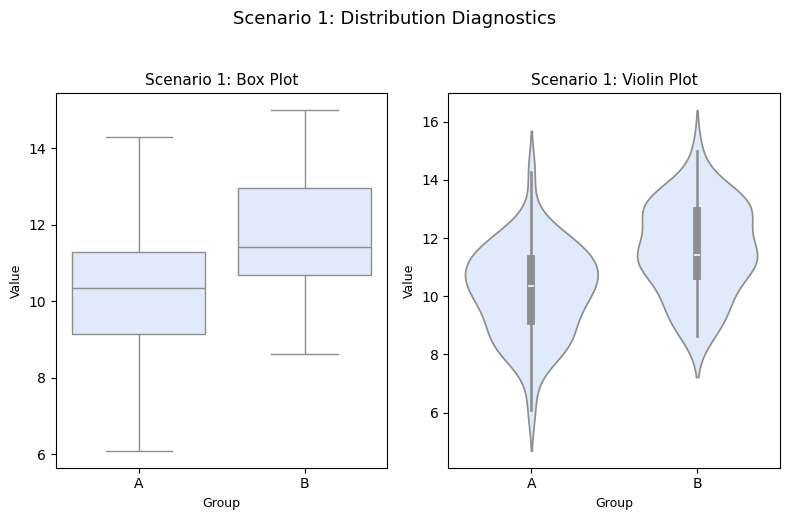

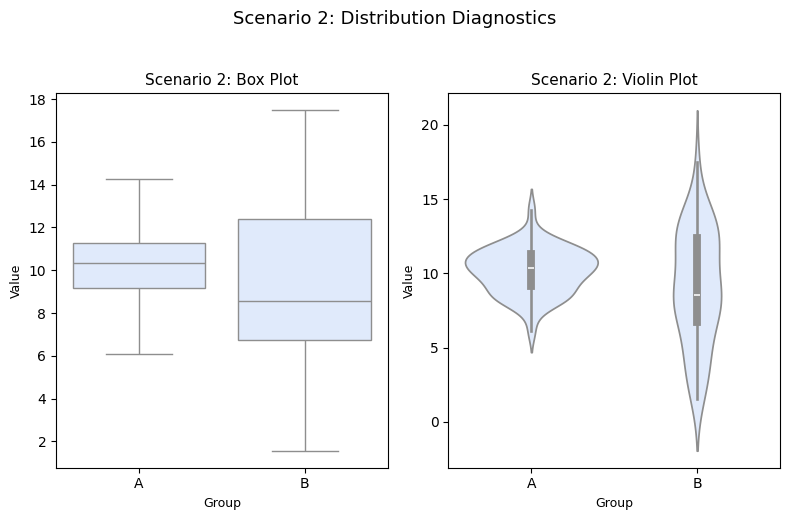

In [ ]:
# ============================================================
# Visual Diagnostics: Box + Violin for df1 and df2
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

pale_blue = "#dbe9ff"

datasets = {
    "Scenario 1": df1,
    "Scenario 2": df2
}

export_names = {
    "Scenario 1": "sim_s1_comparisons_boxplot_violin",
    "Scenario 2": "sim_s2_comparisons_boxplot_violin"
}

for title, df in datasets.items():

    fig, axes = plt.subplots(1, 2, figsize=(8, 5))

    # -------------------------
    # Box plot
    # -------------------------
    sns.boxplot(
        data=df, x="group", y="value",
        ax=axes[0],
        color=pale_blue
    )
    axes[0].set_title(f"{title}: Box Plot", fontsize=11)
    axes[0].set_xlabel("Group", fontsize=9)
    axes[0].set_ylabel("Value", fontsize=9)

    # -------------------------
    # Violin plot
    # -------------------------
    sns.violinplot(
        data=df, x="group", y="value",
        ax=axes[1],
        color=pale_blue
    )
    axes[1].set_title(f"{title}: Violin Plot", fontsize=11)
    axes[1].set_xlabel("Group", fontsize=9)
    axes[1].set_ylabel("Value", fontsize=9)

    fig.suptitle(f"{title}: Distribution Diagnostics", fontsize=13, y=1.03)

    plt.tight_layout()
    plt.show()
    export_plot(fig, export_names[title])

### Welch's t test

In [ ]:
# ============================================================
# Welch's t-test, 95% CI, and SMD for Two Scenarios
# Using df1 and df2 (NO RESIMULATION)
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

# ------------------------------------------------------------
# Helper: Welch 95% CI for mean difference
# ------------------------------------------------------------
def welch_ci(a, b, alpha=0.05):
    mean_diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))

    df = (a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))**2 / (
        (a.var(ddof=1)**2) / (len(a)**2 * (len(a)-1)) +
        (b.var(ddof=1)**2) / (len(b)**2 * (len(b)-1))
    )

    t_crit = stats.t.ppf(1 - alpha/2, df)
    lower = mean_diff - t_crit * se
    upper = mean_diff + t_crit * se
    return lower, upper

# ------------------------------------------------------------
# Scenario 1: Reuse df1
# ------------------------------------------------------------
A1 = df1.loc[df1["group"] == "A", "value"].to_numpy()
B1 = df1.loc[df1["group"] == "B", "value"].to_numpy()

t1, p1 = stats.ttest_ind(A1, B1, equal_var=False)
smd1 = (A1.mean() - B1.mean()) / np.sqrt((A1.var(ddof=1) + B1.var(ddof=1)) / 2)
ci1_low, ci1_high = welch_ci(A1, B1)
decision1 = "Reject H₀" if p1 < 0.05 else "Fail to Reject H₀"

# ------------------------------------------------------------
# Scenario 2: Reuse df2
# ------------------------------------------------------------
A2 = df2.loc[df2["group"] == "A", "value"].to_numpy()
B2 = df2.loc[df2["group"] == "B", "value"].to_numpy()

t2, p2 = stats.ttest_ind(A2, B2, equal_var=False)
smd2 = (A2.mean() - B2.mean()) / np.sqrt((A2.var(ddof=1) + B2.var(ddof=1)) / 2)
ci2_low, ci2_high = welch_ci(A2, B2)
decision2 = "Reject H₀" if p2 < 0.05 else "Fail to Reject H₀"

# ------------------------------------------------------------
# Build Standard pandas DataFrame (NOT Markdown)
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "Concept": [
        "H₀",
        "H₁",
        "mean(A)",
        "mean(B)",
        "Mean Difference",
        "95% CI",
        "t-statistic",
        "p-value",
        "SMD",
        "Decision (α = 0.05)"
    ],
    "Scenario 1": [
        "μₐ = μᵦ",
        "μₐ ≠ μᵦ",
        f"{A1.mean():.3f}",
        f"{B1.mean():.3f}",
        f"{(A1.mean() - B1.mean()):.3f}",
        f"[{ci1_low:.3f}, {ci1_high:.3f}]",
        f"{t1:.3f}",
        f"{p1:.6f}",
        f"{smd1:.3f}",
        decision1
    ],
    "Scenario 2": [
        "μₐ = μᵦ",
        "μₐ ≠ μᵦ",
        f"{A2.mean():.3f}",
        f"{B2.mean():.3f}",
        f"{(A2.mean() - B2.mean()):.3f}",
        f"[{ci2_low:.3f}, {ci2_high:.3f}]",
        f"{t2:.3f}",
        f"{p2:.6f}",
        f"{smd2:.3f}",
        decision2
    ]
})

print(results_df.to_markdown(index=False))

| Concept             | Scenario 1       | Scenario 2        |
|:--------------------|:-----------------|:------------------|
| H₀                  | μₐ = μᵦ          | μₐ = μᵦ           |
| H₁                  | μₐ ≠ μᵦ          | μₐ ≠ μᵦ           |
| mean(A)             | 10.182           | 10.182            |
| mean(B)             | 11.616           | 9.041             |
| Mean Difference     | -1.434           | 1.141             |
| 95% CI              | [-2.043, -0.825] | [-0.025, 2.308]   |
| t-statistic         | -4.672           | 1.954             |
| p-value             | 0.000010         | 0.055041          |
| SMD                 | -0.934           | 0.391             |
| Decision (α = 0.05) | Reject H₀        | Fail to Reject H₀ |


### Non-Parametric Tests

#### Yuen's Trimmed Mean t-test

In [ ]:
# ============================================================
# Yuen's Trimmed Mean t-test (Robust Alternative)
# ============================================================
import numpy as np
from scipy.stats import trim_mean, t

def yuen_ttest(x, y, tr=0.2):
    """
    Yuen's trimmed-mean t-test for two independent samples.

    Parameters
    ----------
    x, y : array-like
        Two independent samples.
    tr : float
        Proportion to trim from each tail (default 0.2 = 20% trimmed mean).

    Returns
    -------
    dict with:
        t_stat : t statistic
        df     : degrees of freedom
        p_val  : two-sided p-value
        diff   : difference in trimmed means
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # Trimmed means
    mx = trim_mean(x, proportiontocut=tr)
    my = trim_mean(y, proportiontocut=tr)

    # Winsorized variances
    g = int(tr * len(x))
    wx = np.sort(x).copy()
    wx[:g] = wx[g]
    wx[-g:] = wx[-g-1]
    vx = np.var(wx, ddof=1)

    g = int(tr * len(y))
    wy = np.sort(y).copy()
    wy[:g] = wy[g]
    wy[-g:] = wy[-g-1]
    vy = np.var(wy, ddof=1)

    # Effective sample sizes
    nx = len(x) - 2 * int(tr * len(x))
    ny = len(y) - 2 * int(tr * len(y))

    # Standard error
    se = np.sqrt(vx / (nx * (nx - 1)) + vy / (ny * (ny - 1)))

    # t statistic
    t_stat = (mx - my) / se

    # Degrees of freedom (Welch-type)
    df = (vx/(nx*(nx-1)) + vy/(ny*(ny-1)))**2 / (
        (vx/(nx*(nx-1)))**2/(nx-1) + (vy/(ny*(ny-1)))**2/(ny-1)
    )

    # Two-sided p-value
    p_val = 2 * (1 - t.cdf(abs(t_stat), df))

    return {
        "t_stat": t_stat,
        "df": df,
        "p_val": p_val,
        "diff": mx - my
    }

# ============================================================
# Scenario 2  Scale Differences  Same Mean and Different Variance
# Yuen trimmed mean test applied to the scale difference case
# ============================================================

x = df2.loc[df2["group"] == "A", "value"].to_numpy()
y = df2.loc[df2["group"] == "B", "value"].to_numpy()


# Run Yuen trimmed mean test
result = yuen_ttest(x, y, tr=0.2)

# Print results
print("Yuen trimmed mean test  tr = 0.2  (H0: trimmed means are equal)")
print("------------------------------------------------")
print(f"t statistic: {result['t_stat']:.4f}")
print(f"degrees of freedom: {result['df']:.2f}")
print(f"difference in trimmed means: {result['diff']:.4f}")
print(f"p value: {result['p_val']:.3e}")

# Final conclusion about H0 using p-value < 0.05 (= alpha)
alpha = 0.05
if result['p_val'] < alpha:
    print("\nReject H0 because p-value < 0.05 (= alpha).")
    print("Conclusion: strong evidence that trimmed means are not the same.")
else:
    print("\nFail to reject H0 because p-value ≥ 0.05 (= alpha).")
    print("Conclusion: no strong evidence that the trimmed means differ.")

Yuen trimmed mean test  tr = 0.2  (H0: trimmed means are equal)
------------------------------------------------
t statistic: 10.0868
degrees of freedom: 37.74
difference in trimmed means: 1.0133
p value: 2.899e-12

Reject H0 because p-value < 0.05 (= alpha).
Conclusion: strong evidence that trimmed means are not the same.


### Distribution Overlap

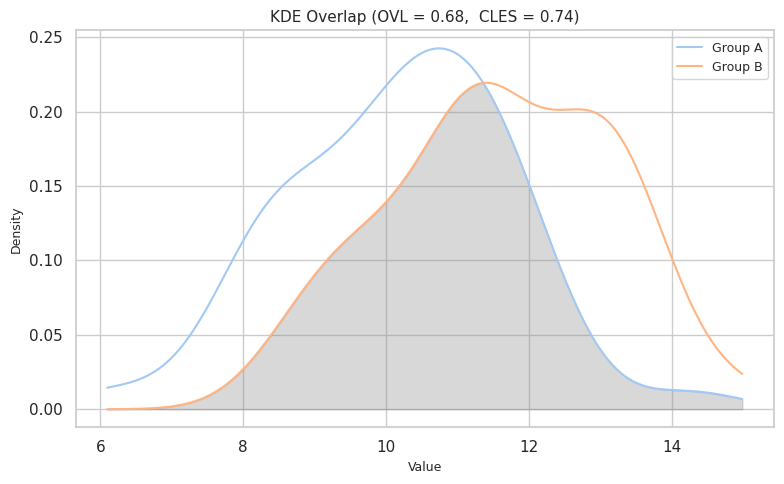

Overlap Coefficient (OVL): 0.677
Common Language Effect Size (CLES): 0.742


In [ ]:
# -----------------------------------------
# Distribution Overlap: KDE + OVL + CLES
# -----------------------------------------

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Extract Scenario 1 data directly from df1
values_a = df1.loc[df1["group"] == "A", "value"].to_numpy()
values_b = df1.loc[df1["group"] == "B", "value"].to_numpy()

# KDEs
kde_a = gaussian_kde(values_a)
kde_b = gaussian_kde(values_b)

# Shared x-range
xmin = min(values_a.min(), values_b.min())
xmax = max(values_a.max(), values_b.max())
xs = np.linspace(xmin, xmax, 500)

# OVL = ∫ min(fA(x), fB(x)) dx (using trapezoid rule)
dens_a = kde_a(xs)
dens_b = kde_b(xs)
ovl = np.trapezoid(np.minimum(dens_a, dens_b), xs)

# CLES = P(B > A)
cles = np.mean(values_b[:, None] > values_a[None, :])

# ------------------------------------------------------------
# Visualization (8×5, pastel colors, fontsize ≥ 9)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

palette = sns.color_palette("pastel")

ax.plot(xs, dens_a, label="Group A", color=palette[0])
ax.plot(xs, dens_b, label="Group B", color=palette[1])

ax.fill_between(xs, np.minimum(dens_a, dens_b),
                alpha=0.3, color="gray")

ax.set_title(f"KDE Overlap (OVL = {ovl:.2f},  CLES = {cles:.2f})", fontsize=11)
ax.set_xlabel("Value", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_comparisons_kde_overlap")

print(f"Overlap Coefficient (OVL): {ovl:.3f}")
print(f"Common Language Effect Size (CLES): {cles:.3f}")

### Test Assumption Checks

In [ ]:
# -----------------------------------------
# Assumption Check: Shapiro–Wilk (Scenario 1 only)
# -----------------------------------------
from scipy.stats import shapiro

# Extract Scenario 1 data directly from df1
values_a = df1.loc[df1["group"] == "A", "value"].to_numpy()
values_b = df1.loc[df1["group"] == "B", "value"].to_numpy()

# Shapiro–Wilk tests
stat_a, p_a = shapiro(values_a)
stat_b, p_b = shapiro(values_b)

print("Shapiro–Wilk Normality Test")
print(f"Group A: W = {stat_a:.3f}, p = {p_a:.3f}")
print(f"Group B: W = {stat_b:.3f}, p = {p_b:.3f}")

Shapiro–Wilk Normality Test
Group A: W = 0.984, p = 0.730
Group B: W = 0.973, p = 0.299


### Q-Q Plots for Distributional Assessment

#### Example 1: Data that fit a normal distribution

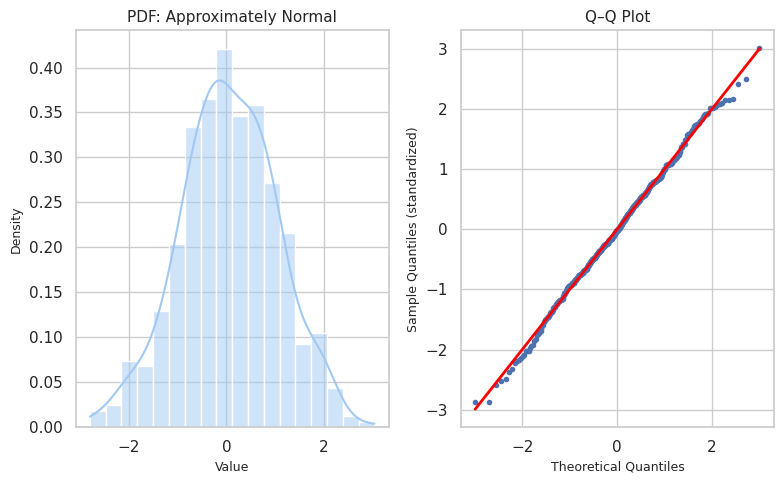

Note: Points fall close to the 45° reference line with only small random deviations.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")

np.random.seed(1)
x = np.random.normal(0, 1, 500)

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.histplot(
    x, kde=True, stat="density", ax=ax[0],
    color=sns.color_palette("pastel")[0]
)
ax[0].set_title("PDF: Approximately Normal", fontsize=11)
ax[0].set_xlabel("Value", fontsize=9)
ax[0].set_ylabel("Density", fontsize=9)
ax[0].grid(True)

# --- Q–Q plot with proper 45° reference line ---

# Standardize sample to N(0,1) scale
x_std = (x - x.mean()) / x.std(ddof=1)

# Get theoretical and sample quantiles
osm, osr = stats.probplot(x_std, dist="norm", fit=False, plot=None)

# Scatter points
ax[1].scatter(osm, osr, s=9)

# Compute true 45° line in quantile units
low = min(osm.min(), osr.min())
high = max(osm.max(), osr.max())
ref = np.linspace(low, high, 200)
ax[1].plot(ref, ref, color="red", linewidth=2)

ax[1].set_title("Q–Q Plot", fontsize=11)
ax[1].set_xlabel("Theoretical Quantiles", fontsize=9)
ax[1].set_ylabel("Sample Quantiles (standardized)", fontsize=9)
ax[1].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_qq_plot_1")

print("Note: Points fall close to the 45° reference line with only small random deviations.")

#### Example 2: Right‑skewed distribution

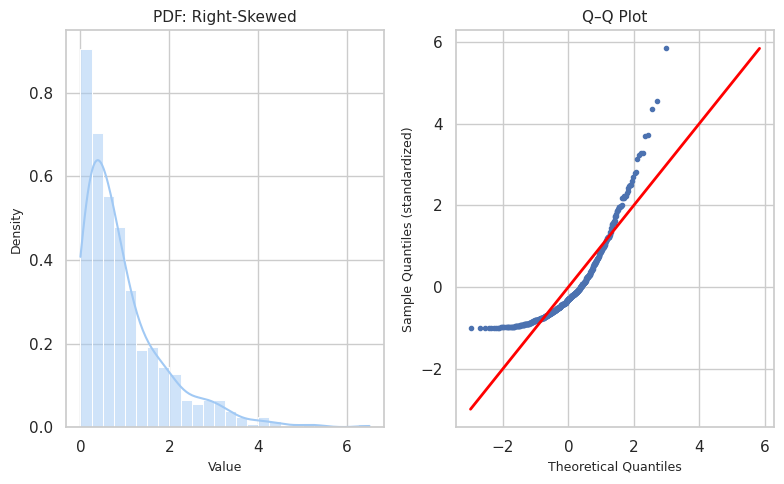

Note: The lower tail lies above the 45° reference line because the exponential distribution has fewer extremely small values than a normal distribution.
The upper tail rises far above the line, reflecting the long right tail.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")

np.random.seed(2)
x = np.random.exponential(scale=1, size=500)

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.histplot(
    x, kde=True, stat="density", ax=ax[0],
    color=sns.color_palette("pastel")[0]
)
ax[0].set_title("PDF: Right‑Skewed", fontsize=11)
ax[0].set_xlabel("Value", fontsize=9)
ax[0].set_ylabel("Density", fontsize=9)
ax[0].grid(True)

# --- Q–Q plot with proper 45° reference line ---

# Standardize sample to N(0,1) scale
x_std = (x - x.mean()) / x.std(ddof=1)

# Get theoretical and sample quantiles
osm, osr = stats.probplot(x_std, dist="norm", fit=False, plot=None)

# Scatter points
ax[1].scatter(osm, osr, s=9)

# Compute true 45° line in quantile units
low = min(osm.min(), osr.min())
high = max(osm.max(), osr.max())
ref = np.linspace(low, high, 200)
ax[1].plot(ref, ref, color="red", linewidth=2)

ax[1].set_title("Q–Q Plot", fontsize=11)
ax[1].set_xlabel("Theoretical Quantiles", fontsize=9)
ax[1].set_ylabel("Sample Quantiles (standardized)", fontsize=9)
ax[1].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_qq_plot_2")

print("Note: The lower tail lies above the 45° reference line because the exponential distribution has fewer extremely small values than a normal distribution.")
print("The upper tail rises far above the line, reflecting the long right tail.")

#### Example 3: Heavy‑tailed distribution

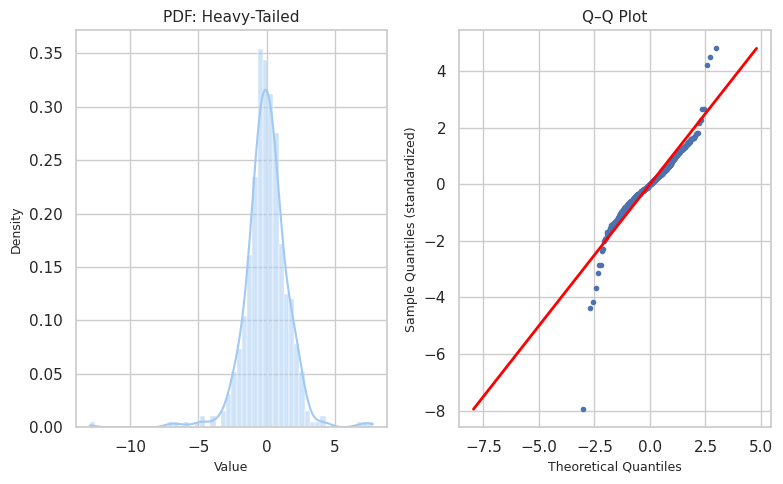

Note: Both tails deviate away from the 45° reference line, indicating heavy tails.


In [ ]:
np.random.seed(3)
x = stats.t(df=3).rvs(size=500)

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.histplot(
    x, kde=True, stat="density", ax=ax[0],
    color=sns.color_palette("pastel")[0]
)
ax[0].set_title("PDF: Heavy‑Tailed", fontsize=11)
ax[0].set_xlabel("Value", fontsize=9)
ax[0].set_ylabel("Density", fontsize=9)
ax[0].grid(True)

# --- Q–Q plot with proper 45° reference ---

# standardize to N(0,1) scale
x_std = (x - x.mean()) / x.std(ddof=1)

osm, osr = stats.probplot(x_std, dist="norm", fit=False, plot=None)

ax[1].scatter(osm, osr, s=9)

low = min(osm.min(), osr.min())
high = max(osm.max(), osr.max())
ref = np.linspace(low, high, 200)
ax[1].plot(ref, ref, color="red", linewidth=2)

ax[1].set_title("Q–Q Plot", fontsize=11)
ax[1].set_xlabel("Theoretical Quantiles", fontsize=9)
ax[1].set_ylabel("Sample Quantiles (standardized)", fontsize=9)
ax[1].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_qq_plot_3")

print("Note: Both tails deviate away from the 45° reference line, indicating heavy tails.")

#### Example 4: Light‑tailed distribution

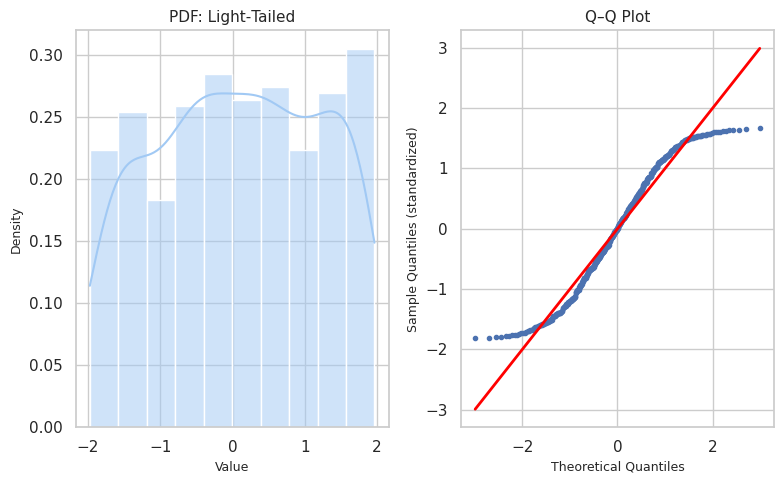

Note: Both tails curve inward toward the 45° reference line,
creating a gentle S‑shape that reflects lighter‑than‑Normal tails.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")

np.random.seed(4)
x = np.random.uniform(-2, 2, size=500)

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.histplot(
    x, kde=True, stat="density", ax=ax[0],
    color=sns.color_palette("pastel")[0]
)
ax[0].set_title("PDF: Light‑Tailed", fontsize=11)
ax[0].set_xlabel("Value", fontsize=9)
ax[0].set_ylabel("Density", fontsize=9)
ax[0].grid(True)

# --- Q–Q plot with proper 45° reference line ---

# Standardize sample to N(0,1) scale
x_std = (x - x.mean()) / x.std(ddof=1)

# Get theoretical and sample quantiles
osm, osr = stats.probplot(x_std, dist="norm", fit=False, plot=None)

# Scatter points
ax[1].scatter(osm, osr, s=9)

# Compute true 45° line in quantile units
low = min(osm.min(), osr.min())
high = max(osm.max(), osr.max())
ref = np.linspace(low, high, 200)
ax[1].plot(ref, ref, color="red", linewidth=2)

ax[1].set_title("Q–Q Plot", fontsize=11)
ax[1].set_xlabel("Theoretical Quantiles", fontsize=9)
ax[1].set_ylabel("Sample Quantiles (standardized)", fontsize=9)
ax[1].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_qq_plot_4")

print("Note: Both tails curve inward toward the 45° reference line,")
print("creating a gentle S‑shape that reflects lighter‑than‑Normal tails.")

#### Example 5: Outliers

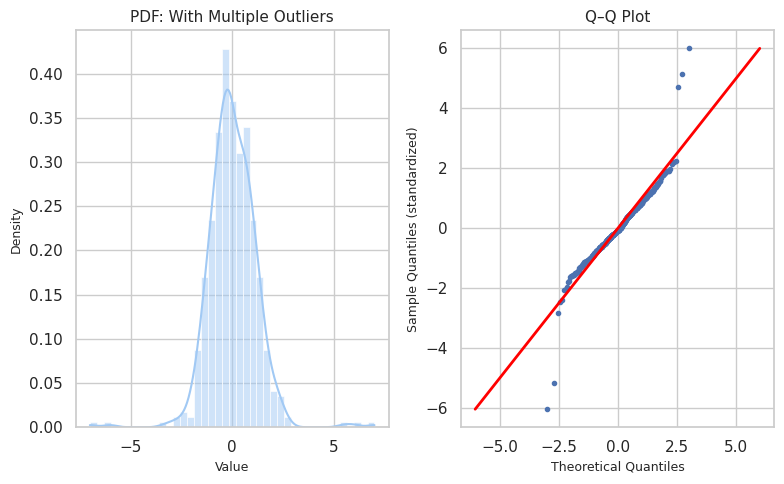

Note: Several points fall far from the 45° reference line, making the outliers immediately visible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

sns.set(style="whitegrid")

np.random.seed(5)
x = np.random.normal(size=500)

# add several outliers
x[:5] = [6, 7, -6, 5.5, -7]

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# PDF
sns.histplot(
    x, kde=True, stat="density", ax=ax[0],
    color=sns.color_palette("pastel")[0]
)
ax[0].set_title("PDF: With Multiple Outliers", fontsize=11)
ax[0].set_xlabel("Value", fontsize=9)
ax[0].set_ylabel("Density", fontsize=9)
ax[0].grid(True)

# --- Q–Q plot with proper 45° reference line ---

# Standardize sample to N(0,1) scale
x_std = (x - x.mean()) / x.std(ddof=1)

# Get theoretical and sample quantiles
osm, osr = stats.probplot(x_std, dist="norm", fit=False, plot=None)

# Scatter points
ax[1].scatter(osm, osr, s=9)

# Compute true 45° line in quantile units
low = min(osm.min(), osr.min())
high = max(osm.max(), osr.max())
ref = np.linspace(low, high, 200)
ax[1].plot(ref, ref, color="red", linewidth=2)

ax[1].set_title("Q–Q Plot", fontsize=11)
ax[1].set_xlabel("Theoretical Quantiles", fontsize=9)
ax[1].set_ylabel("Sample Quantiles (standardized)", fontsize=9)
ax[1].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_qq_plot_5")

print("Note: Several points fall far from the 45° reference line, making the outliers immediately visible.")

## Association Measures

### Simulated Data for Association Measures

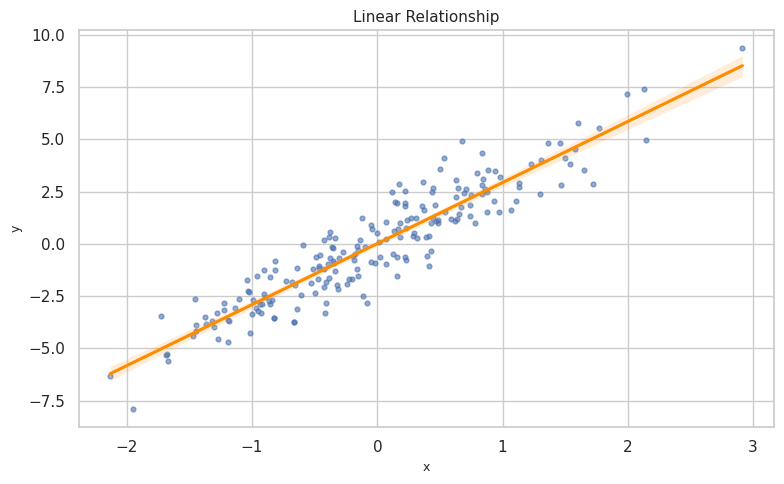

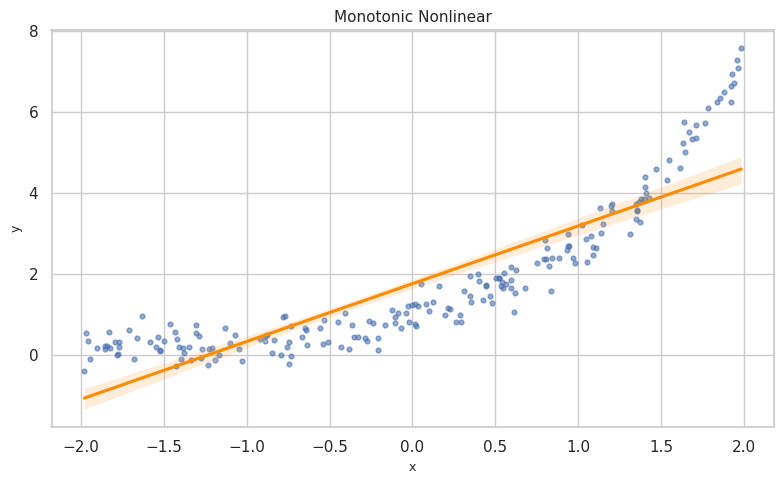

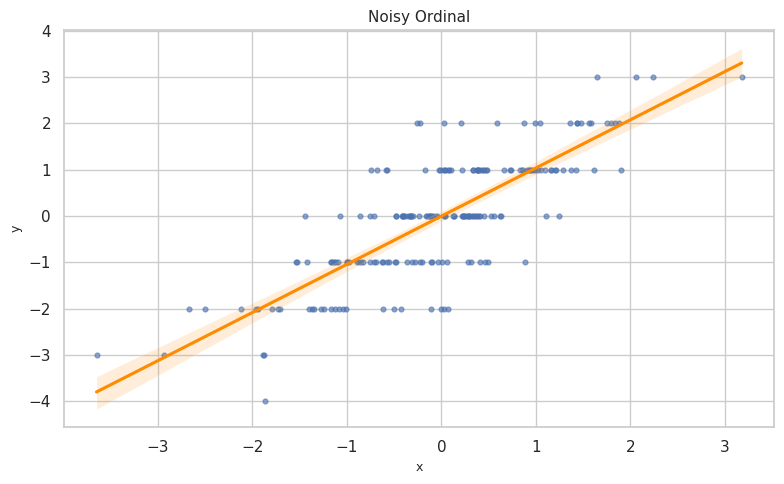

In [ ]:
# ------------------------------------------------------------
# Simulated Data for Association Measures
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Seed for reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

n = 200

# ------------------------------------------------------------
# Linear Relationship (Pearson strong, Spearman strong)
# ------------------------------------------------------------
x_lin = rng.normal(0, 1, n)
y_lin = 3 * x_lin + rng.normal(0, 1, n)

df_lin = pd.DataFrame({
    "x": x_lin,
    "y": y_lin,
    "scenario": "Linear Relationship"
})

# ------------------------------------------------------------
# Monotonic Nonlinear (Pearson weaker, Spearman strong)
# ------------------------------------------------------------
x_mon = rng.uniform(-2, 2, n)
y_mon = np.exp(x_mon) + rng.normal(0, 0.3, n)

df_mon = pd.DataFrame({
    "x": x_mon,
    "y": y_mon,
    "scenario": "Monotonic Nonlinear"
})

# ------------------------------------------------------------
# Noisy Ordinal (Kendall’s τ more stable)
# ------------------------------------------------------------
x_ord = rng.normal(0, 1, n)
y_ord = np.round(x_ord + rng.normal(0, 0.8, n))  # discretized + noise

df_ord = pd.DataFrame({
    "x": x_ord,
    "y": y_ord,
    "scenario": "Noisy Ordinal"
})

# ------------------------------------------------------------
# Combine all scenarios
# ------------------------------------------------------------
df_all = pd.concat([df_lin, df_mon, df_ord], ignore_index=True)

# ------------------------------------------------------------
# Visualization: Compare All Three Scenarios
# ------------------------------------------------------------

# ------------------------------------------------------------
# Visualization: Compare All Three Scenarios (Updated)
# ------------------------------------------------------------

scenarios = [
    ("Linear Relationship", "sim_linear"),
    ("Monotonic Nonlinear", "sim_monotonic_nonlinear"),
    ("Noisy Ordinal", "sim_noisy_ordinal")
]

for scen, fname in scenarios:
    df_sub = df_all[df_all["scenario"] == scen]

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.regplot(
        data=df_sub, x="x", y="y",
        scatter_kws={"alpha": 0.6, "s": 12},   # smaller points
        line_kws={"color": "darkorange"}
    )

    ax.set_title(f"{scen}", fontsize=11)
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylabel("y", fontsize=9)
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    export_plot(fig, fname)


### Pearson’s r, Spearman’s ρ and Kendall’s τ Tests


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ------------------------------------------------------------
# Function to compute correlations and filter by p < 0.01
# ------------------------------------------------------------
def compute_effect_sizes(df):
    x = df["x"]
    y = df["y"]

    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_rho, spearman_p = stats.spearmanr(x, y)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    return {
        "Pearson": f"{pearson_r:.3f}" if pearson_p < 0.01 else "",
        "Spearman": f"{spearman_rho:.3f}" if spearman_p < 0.01 else "",
        "Kendall": f"{kendall_tau:.3f}" if kendall_p < 0.01 else ""
    }

# ------------------------------------------------------------
# Compute correlations for each scenario
# ------------------------------------------------------------
results = {}

for scen in ["Linear Relationship", "Monotonic Nonlinear", "Noisy Ordinal"]:
    df_sub = df_all[df_all["scenario"] == scen]
    results[scen] = compute_effect_sizes(df_sub)

# ------------------------------------------------------------
# Build summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame(results).T[
    ["Pearson", "Spearman", "Kendall"]
]

summary_df.index.name = "Scenario"
summary_df.title = "Correlation Effect Sizes (only reported when p < 0.01)"

print(summary_df.title)
summary_df

Correlation Effect Sizes (only reported when p < 0.01)


,Pearson,Spearman,Kendall
Scenario,,,
Linear Relationship,0.930,0.926,0.762
Monotonic Nonlinear,0.877,0.936,0.800
Noisy Ordinal,0.798,0.765,0.631
